In [1]:
# 1. Imports and Environment Setup
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Available GPUs: {len(tf.config.list_physical_devices('GPU'))}")


TensorFlow Version: 2.21.0


Available GPUs: 0


In [2]:
# 2.1 Download or locate the Kaggle dataset
import kagglehub

try:
    raw_dataset_path = kagglehub.dataset_download('miadul/animal-image-classification-5-species')
    print(f"Dataset successfully downloaded to: {raw_dataset_path}")
except Exception as e:
    raw_dataset_path = os.path.expanduser(r'~/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1')
    print(f"Using local cached dataset path: {raw_dataset_path}")

# Locate animals_dataset root
dataset_root = os.path.join(raw_dataset_path, 'animals_dataset')
if not os.path.exists(dataset_root):
    dataset_root = raw_dataset_path

print(f"Dataset Root: {dataset_root}")
print("Subdirectories:", os.listdir(dataset_root))


Dataset successfully downloaded to: C:\Users\shahz\.cache\kagglehub\datasets\miadul\animal-image-classification-5-species\versions\1
Dataset Root: C:\Users\shahz\.cache\kagglehub\datasets\miadul\animal-image-classification-5-species\versions\1\animals_dataset
Subdirectories: ['test', 'train', 'validation']


In [3]:
# 2.2 Inspect Class Distribution Across Splits
splits = ['train', 'validation', 'test']
raw_classes = sorted(os.listdir(os.path.join(dataset_root, 'train')))

# Mapping dictionary for clean display labels
CLASS_LABEL_MAP = {
    'cat': 'Cat',
    'cow': 'Cow',
    'deep': 'Deer',
    'dog': 'Dog',
    'lion': 'Lion'
}

split_data = []
for s in splits:
    split_path = os.path.join(dataset_root, s)
    for c in raw_classes:
        class_folder = os.path.join(split_path, c)
        count = len(os.listdir(class_folder)) if os.path.exists(class_folder) else 0
        split_data.append({
            'Split': s.capitalize(),
            'Raw Folder': c,
            'Species': CLASS_LABEL_MAP.get(c, c.capitalize()),
            'Count': count
        })

split_df = pd.DataFrame(split_data)
pivot_df = split_df.pivot(index='Species', columns='Split', values='Count')[['Train', 'Validation', 'Test']]
pivot_df['Total'] = pivot_df.sum(axis=1)

print("=== 5-Species Dataset Summary ===")
print(pivot_df.to_string())


=== 5-Species Dataset Summary ===
Split    Train  Validation  Test  Total
Species                                
Cat         91          17    17    125
Cow         86          15    16    117
Deer        87          17    16    120
Dog        111          17    16    144
Lion        89          17    17    123


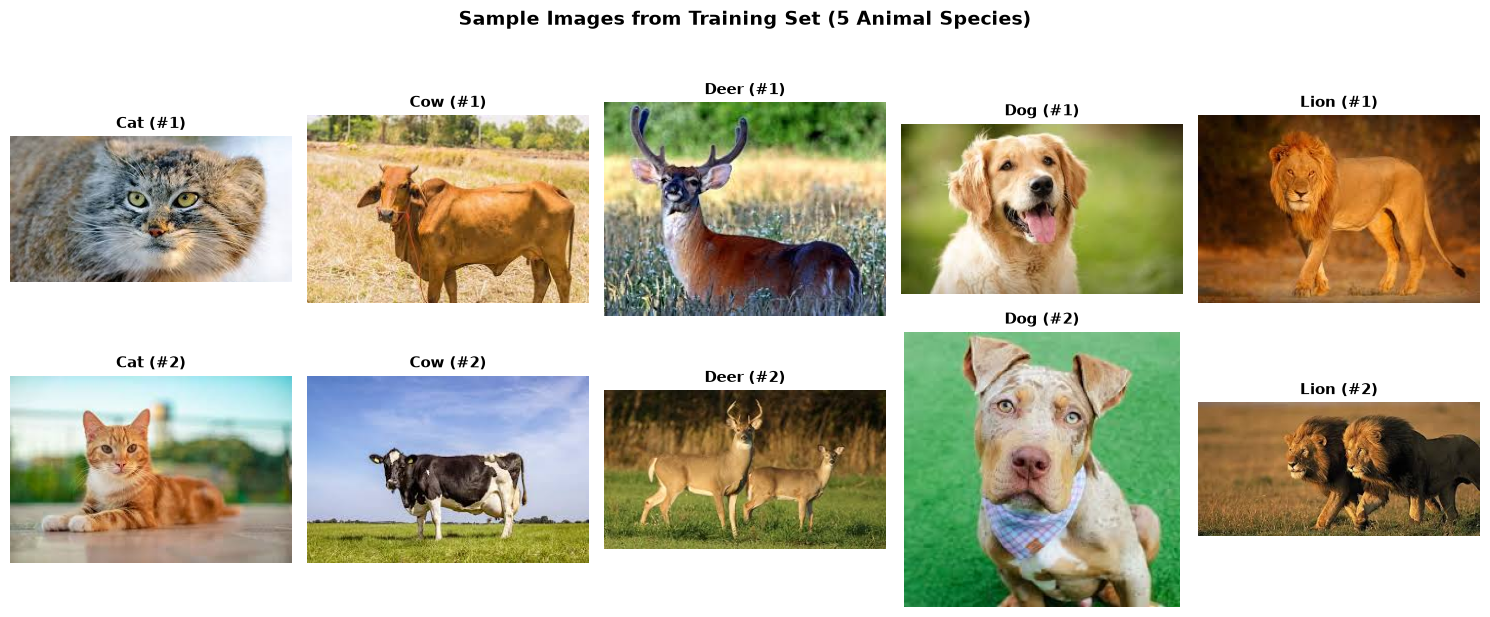

In [4]:
# 3.1 Display Sample Images for Each Species
train_dir = os.path.join(dataset_root, 'train')

plt.figure(figsize=(15, 6))

for col_idx, raw_c in enumerate(raw_classes):
    class_folder = os.path.join(train_dir, raw_c)
    file_names = os.listdir(class_folder)
    
    # Show 2 random samples per class
    for row_idx in range(2):
        img_name = random.choice(file_names)
        img_path = os.path.join(class_folder, img_name)
        img = Image.open(img_path)
        
        ax = plt.subplot(2, 5, row_idx * 5 + col_idx + 1)
        ax.imshow(img)
        species_title = CLASS_LABEL_MAP.get(raw_c, raw_c.capitalize())
        ax.set_title(f"{species_title} (#{row_idx+1})", fontsize=11, fontweight='bold')
        ax.axis('off')

plt.suptitle("Sample Images from Training Set (5 Animal Species)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


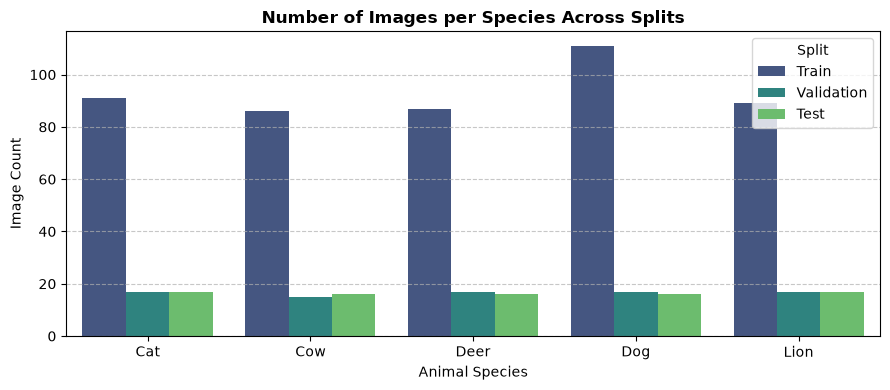

In [5]:
# 3.2 Plot Class Distribution
plt.figure(figsize=(9, 4))
sns.barplot(data=split_df, x='Species', y='Count', hue='Split', palette='viridis')
plt.title("Number of Images per Species Across Splits", fontsize=12, fontweight='bold')
plt.xlabel("Animal Species")
plt.ylabel("Image Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Split")
plt.tight_layout()
plt.show()


In [6]:
# 4.1 Load Datasets using tf.keras.utils.image_dataset_from_directory
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'validation'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

detected_classes = train_ds.class_names
display_classes = [CLASS_LABEL_MAP.get(c, c.capitalize()) for c in detected_classes]
print(f"Detected Folder Classes: {detected_classes}")
print(f"Display Species Names:   {display_classes}")

# 4.2 Data Augmentation Pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

# 4.3 Configure Performance Prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Data pipelines ready.")


Found 464 files belonging to 5 classes.


Found 83 files belonging to 5 classes.


Found 82 files belonging to 5 classes.


Detected Folder Classes: ['cat', 'cow', 'deep', 'dog', 'lion']
Display Species Names:   ['Cat', 'Cow', 'Deer', 'Dog', 'Lion']
Data pipelines ready.


## 5. Multi-Class CNN Architecture Design

We build a custom multi-class **Convolutional Neural Network (CNN)**:
- **Input Layer**: Accepts (150, 150, 3) images.
- **Data Augmentation Layer**: Synthesizes geometric perturbations to broaden generalization.
- **Rescaling**: Scales pixel intensities from `[0, 255]` to `[0.0, 1.0]`.
- **4 Feature Extraction Blocks**:
  - `Conv2D` with progressive channel depths: 32 → 64 → 128 → 256.
  - `BatchNormalization`: Accelerates convergence and regularizes feature activations.
  - `ReLU` Non-linear Activation.
  - `MaxPooling2D` (2x2): Reduces spatial dimensions while preserving translational invariance.
- **Classification Head**:
  - `GlobalAveragePooling2D`: Collapses spatial dimensions into 256 feature descriptors with zero parameter explosion.
  - `Dense` (256 units, ReLU) + `Dropout` (0.4) for regularization.
  - `Dense` (5 units, Softmax activation) outputting probability distribution $\sum_{i=1}^5 P_i = 1$.


In [7]:
# 5.1 Define 5-Species Animal Classifier CNN
def build_animal_classifier(input_shape=(150, 150, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape)
    
    # Augmentation and Rescaling
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)
    
    # Block 1: 32 filters
    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 2: 64 filters
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 3: 128 filters
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 4: 256 filters
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Dense Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="species_probabilities")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="Animal_Classifier_5_Species")
    return model

model = build_animal_classifier()
model.summary()


Model: "Animal_Classifier_5_Species"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 456,933 (1.74 MB)

 Trainable params: 455,973 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# 6.1 Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')
    ]
)

# 6.2 Define Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr]


In [9]:
# 7.1 Train the Model
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)


Epoch 1/15


c:\Users\shahz\anaconda3\envs\ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



 1/15 ━━━━━━━━━━━━━━━━━━━━ 1:10 5s/step - accuracy: 0.2812 - loss: 1.7574 - top_2_accuracy: 0.5000


 2/15 ━━━━━━━━━━━━━━━━━━━━ 11s 877ms/step - accuracy: 0.2656 - loss: 1.9257 - top_2_accuracy: 0.4688


 3/15 ━━━━━━━━━━━━━━━━━━━━ 10s 874ms/step - accuracy: 0.2500 - loss: 1.9490 - top_2_accuracy: 0.4479

...


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 979ms/step - accuracy: 0.5496 - loss: 1.1495 - top_2_accuracy: 0.7651


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5496 - loss: 1.1495 - top_2_accuracy: 0.7651 - val_accuracy: 0.2892 - val_loss: 1.6946 - val_top_2_accuracy: 0.4458 - learning_rate: 2.5000e-04


Epoch 8: early stopping


Restoring model weights from the end of the best epoch: 2.


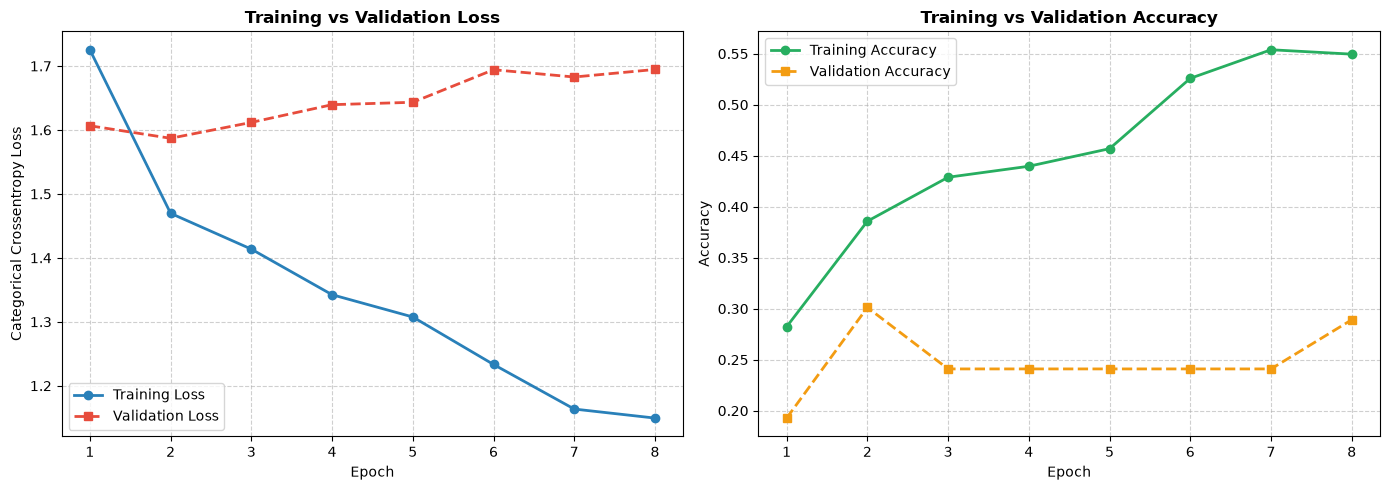

In [10]:
# 8.1 Plot Training & Validation Curves
history_dict = history.history
epochs_range = range(1, len(history_dict['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
axes[0].plot(epochs_range, history_dict['loss'], 'o-', label='Training Loss', color='#2980b9', lw=2)
axes[0].plot(epochs_range, history_dict['val_loss'], 's--', label='Validation Loss', color='#e74c3c', lw=2)
axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Accuracy Plot
axes[1].plot(epochs_range, history_dict['accuracy'], 'o-', label='Training Accuracy', color='#27ae60', lw=2)
axes[1].plot(epochs_range, history_dict['val_accuracy'], 's--', label='Validation Accuracy', color='#f39c12', lw=2)
axes[1].set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


Test Loss:           1.5941
Test Top-1 Accuracy: 35.37%
Test Top-2 Accuracy: 48.78%


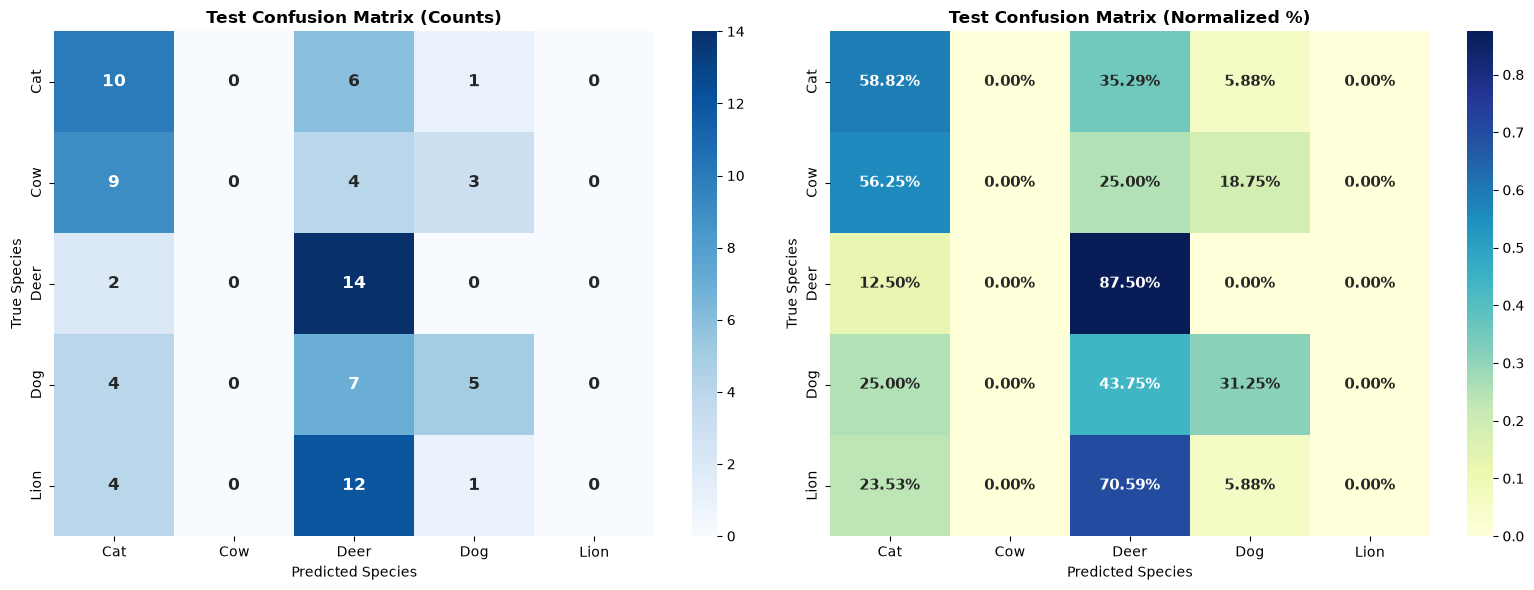


=== Multi-Class Classification Report ===
              precision    recall  f1-score   support

         Cat     0.3448    0.5882    0.4348        17
         Cow     0.0000    0.0000    0.0000        16
        Deer     0.3256    0.8750    0.4746        16
         Dog     0.5000    0.3125    0.3846        16
        Lion     0.0000    0.0000    0.0000        17

    accuracy                         0.3537        82
   macro avg     0.2341    0.3551    0.2588        82
weighted avg     0.2326    0.3537    0.2578        82



c:\Users\shahz\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shahz\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shahz\anaconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
# 8.2 Test Set Evaluation
test_results = model.evaluate(test_ds, verbose=0)
print(f"Test Loss:           {test_results[0]:.4f}")
print(f"Test Top-1 Accuracy: {test_results[1] * 100:.2f}%")
print(f"Test Top-2 Accuracy: {test_results[2] * 100:.2f}%")

# 8.3 Generate Predictions for Confusion Matrix
y_true_indices = []
y_pred_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true_indices.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(probs)

y_true_indices = np.array(y_true_indices)
y_pred_probs = np.array(y_pred_probs)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# 8.4 Confusion Matrix
cm = confusion_matrix(y_true_indices, y_pred_indices)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_classes, yticklabels=display_classes, ax=axes[0],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title("Test Confusion Matrix (Counts)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Species")
axes[0].set_ylabel("True Species")

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlGnBu',
            xticklabels=display_classes, yticklabels=display_classes, ax=axes[1],
            annot_kws={"size": 11, "weight": "bold"})
axes[1].set_title("Test Confusion Matrix (Normalized %)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted Species")
axes[1].set_ylabel("True Species")

plt.tight_layout()
plt.show()

# 8.5 Classification Report
print("\n=== Multi-Class Classification Report ===")
print(classification_report(y_true_indices, y_pred_indices, target_names=display_classes, digits=4))



--- Testing Class: Cat ---


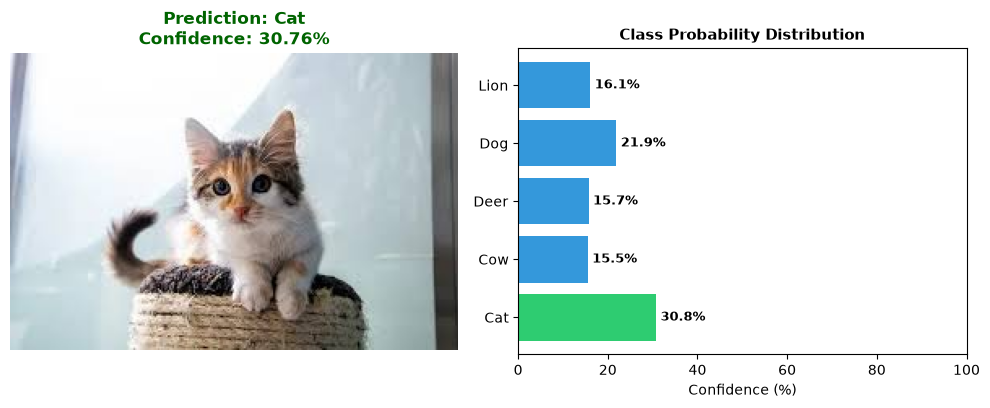


--- Testing Class: Cow ---


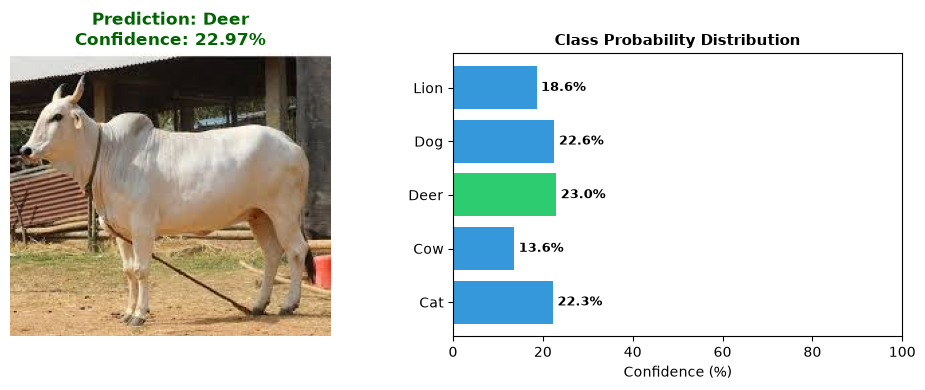


--- Testing Class: Deer ---


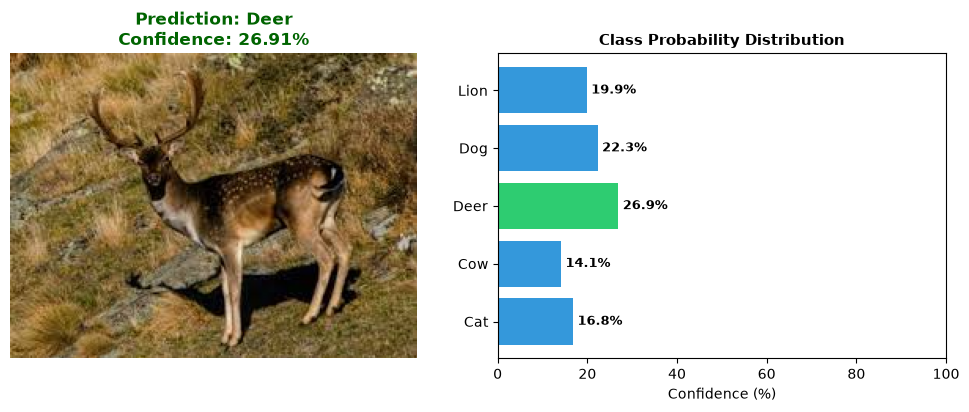


--- Testing Class: Dog ---


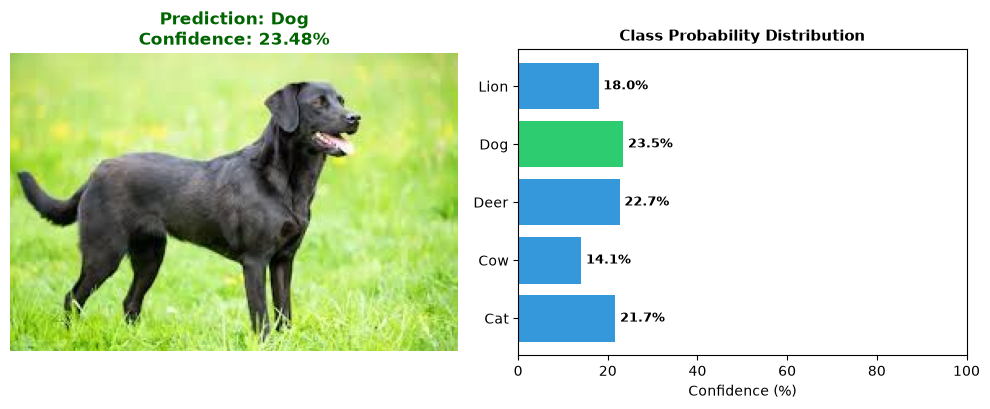


--- Testing Class: Lion ---


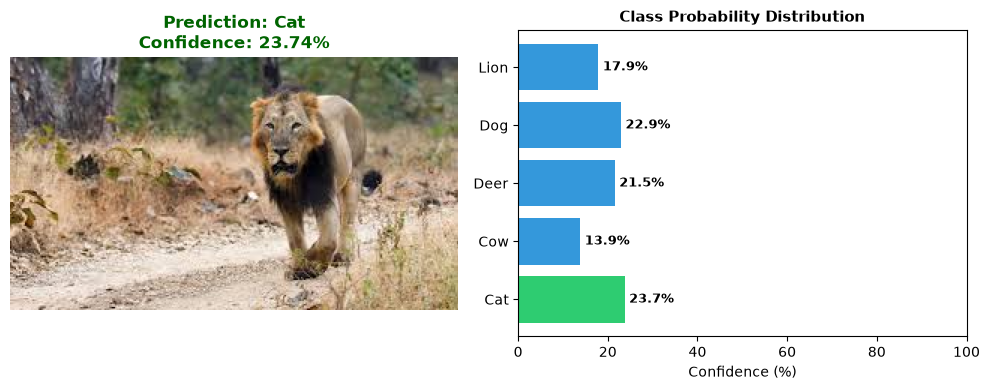

In [12]:
# 9.1 Inference Function with Probability Bar Chart
def predict_animal_species(image_path, model):
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((150, 150))
    img_array = np.array(img_resized, dtype=np.float32)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Predict probabilities
    probs = model.predict(img_batch, verbose=0)[0]
    top_idx = np.argmax(probs)
    predicted_species = display_classes[top_idx]
    confidence = probs[top_idx] * 100
    
    # Plot Image and Probabilities side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Image
    axes[0].imshow(img)
    axes[0].set_title(f"Prediction: {predicted_species}\nConfidence: {confidence:.2f}%", 
                      color='darkgreen', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Probability Bar Chart
    colors = ['#3498db' if i != top_idx else '#2ecc71' for i in range(len(display_classes))]
    bars = axes[1].barh(display_classes, probs * 100, color=colors)
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Confidence (%)", fontsize=10)
    axes[1].set_title("Class Probability Distribution", fontsize=11, fontweight='bold')
    
    # Add data labels to bars
    for bar in bars:
        width = bar.get_width()
        axes[1].text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%",
                     va='center', fontsize=9, fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    return predicted_species, confidence

# 9.2 Test on Unseen Test Set Images Across Different Species
test_dir = os.path.join(dataset_root, 'test')

for raw_c in raw_classes:
    folder = os.path.join(test_dir, raw_c)
    if os.path.exists(folder) and os.listdir(folder):
        sample_img = os.path.join(folder, os.listdir(folder)[0])
        species_name = CLASS_LABEL_MAP.get(raw_c, raw_c.capitalize())
        print(f"\n--- Testing Class: {species_name} ---")
        predict_animal_species(sample_img, model)
